# Vectors and Matrices Basics

## 📚 Learning Objectives

By completing this notebook, you will:
- Perform vector and matrix operations with NumPy
- Understand shapes, broadcasting, and basic linear algebra
- Apply operations to simple ML-relevant examples

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — the Titanic table you loaded there is exactly the matrix `X` we now do algebra on.

**Used later in:** Course 04 (AIAT 114) — Unit 4 — PCA compresses that same feature matrix.

---


---

## 📌 Real case: `king − man + woman ≈ queen`

In 2013 Tomas Mikolov and colleagues at Google released **word2vec**, which represents every word as a
vector of a few hundred numbers. The striking result was that ordinary vector *arithmetic* on those
vectors carried meaning: take the vector for `king`, subtract `man`, add `woman`, and the nearest vector
in the entire vocabulary is `queen`. Nothing in the training told the model what a queen is — the
relationship fell out of the geometry.

Three years later Bolukbasi, Chang, Zou, Saligrama and Kalai ran the same arithmetic on the same publicly
released Google-News vectors and got results nobody wanted. In their words, "even word embeddings trained
on Google News articles exhibit female/male gender stereotypes to a disturbing extent": the same direction
that separates *he* from *she* also drags `receptionist` toward female. Their 2016 paper is titled
*"Man is to Computer Programmer as Woman is to Homemaker? Debiasing Word Embeddings."* Vector arithmetic
did not invent the bias. It made it **measurable**, and then it made it **executable** by every system
built on those vectors.

**What goes wrong without this.** If you cannot see your data as vectors, "how similar are these two
things?" has no answer you can compute. Every recommender, every search ranking, every duplicate-detector
in this diploma reduces to distances and angles between rows of a matrix. And the flip side matters just
as much: once your data is vectors, arithmetic on it is cheap and unsupervised — which is exactly how an
unexamined embedding hands a hiring filter a stereotype it absorbed from a news archive.

**The same reasoning appears elsewhere:** a patient's lab panel as one vector so two patients can be
compared; a network connection in CICIDS2017 as a vector of packet statistics so an intrusion detector
can flag the unusual one; a house as `[size, bedrooms, age]` — the very vector built below.


# Vectors and Matrices Basics

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have:
- ✅ **Python 3.8+ installed** and working
- ✅ **Basic Python knowledge**: Variables, data types, lists
- ✅ **NumPy installed**: `pip install numpy`
- ✅ **Understanding of data**: What is a number? What is a list?

**If you haven't completed these**, you might struggle with:
- Understanding array operations
- Understanding data structures
- Using NumPy functions

---

## 🔗 Where This Notebook Fits

**This is the FIRST example** - it's the foundation for all ML mathematics!

**Why this example FIRST?**
- **Before** you can do matrix operations, you need to understand vectors and matrices
- **Before** you can compute gradients, you need to understand vector representation
- **Before** you can use ML algorithms, you need to understand how data is structured

**Builds on**: Python basics (variables, data structures)

**Leads to**: 
- 📓 Example 2: Matrix Operations (needs vector/matrix understanding)
- 📓 Example 3: Eigenvalues (needs matrix understanding)
- 📓 Module 02: Gradients (needs vector understanding)

---

## The Story: Understanding Before Using

Imagine you're organizing a library. **Before** you can organize books, you need to understand what a book is - its structure, its properties. **After** understanding books, you can organize them efficiently!

Same with machine learning: **Before** building models, we understand data structure - vectors represent single data points, matrices represent multiple data points. **After** understanding structure, we can process data efficiently!

---

## Why This Concept Matters

### Why Vectors and Matrices Matter in ML

**WHY** are vectors and matrices fundamental to machine learning?

1. **Data Representation**: 
   - **WHY**: ML algorithms need structured data
   - **HOW**: Vectors represent single data points, matrices represent multiple data points
   - **AFTER**: Enables efficient batch processing

2. **Computational Efficiency**:
   - **WHY**: Process thousands of samples simultaneously
   - **HOW**: Matrix operations are optimized in NumPy
   - **AFTER**: Training models becomes feasible

3. **Neural Network Foundation**:
   - **WHY**: Neural networks are built on matrix operations
   - **HOW**: Each layer multiplies weight matrices by data matrices
   - **AFTER**: Enables deep learning

**Common Student Questions:**
- **Q: What's the difference between a vector and a matrix?**
  - Answer: Vector = 1D array (one row or one column), Matrix = 2D array (rows and columns)
  - Vector: [1, 2, 3] = single data point with 3 features
  - Matrix: [[1,2,3], [4,5,6]] = two data points, each with 3 features
  - In ML: Vector = one sample, Matrix = batch of samples
- **Q: Why use NumPy arrays instead of Python lists?**
  - Answer: NumPy = faster (C code), optimized for math operations
  - Lists: Slow for math, no built-in operations
  - Arrays: Fast vectorized operations (add, multiply entire arrays at once)
  - Example: `array1 + array2` adds all elements → much faster than loops
- **Q: What does "shape" mean in NumPy?**
  - Answer: Shape = dimensions (rows, columns)
  - Shape (3,) = 1D array with 3 elements (vector)
  - Shape (3, 4) = 2D array with 3 rows, 4 columns (matrix)
  - Shape (2, 3, 4) = 3D array (2 matrices, each 3x4)
  - Important: Shape tells you data structure!
- **Q: Why do ML algorithms need matrices?**
  - Answer: ML processes many samples at once (batch processing)
  - Matrix = batch of samples → process all at once → faster
  - Example: 1000 images → matrix 1000x784 → process all in one operation
  - Without matrices: Process one by one → 1000x slower!
- **Q: What is vectorization?**
  - Answer: Vectorization = operations on entire arrays at once
  - Instead of: Loop through each element
  - Use: Array operations (add, multiply entire arrays)
  - Example: `result = array1 * array2` → multiplies all elements at once
  - Why: Much faster (uses optimized C code, parallel processing)

## Learning Objectives
1. Create vectors and matrices in NumPy
2. Understand vector vs matrix representation
3. Access and manipulate array elements
4. Understand shape and dimensions
5. See how ML algorithms use this structure
6. Visualize data organization

---

## Step 1: Import necessary libraries

These libraries help us work with linear algebra and create visualizations

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: load the two libraries this lesson relies on.
# NumPy supplies the vector/matrix objects and math; Matplotlib draws the figures that make them visible.

import numpy as np  # For linear algebra operations
import matplotlib.pyplot as plt  # For creating plots and visualizations

# Confirm the environment is ready before any math starts.
print('✅ Libraries imported successfully!')
print('\n📚 What each library does:')
print('   - numpy: Linear algebra operations (vectors, matrices, math)')
print('   - matplotlib: Create plots and visualizations')

✅ Libraries imported successfully!

📚 What each library does:
   - numpy: Linear algebra operations (vectors, matrices, math)
   - matplotlib: Create plots and visualizations


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this concept works in ML!

**Why this matters**: Understanding implementation is key to using concepts effectively!

## Step 1: Creating Vectors

**BEFORE**: We have individual numbers but can't represent a data point efficiently.

**AFTER**: We'll create vectors that represent single data points with multiple features!

**Why vectors?** A data point in ML has multiple features (like a house with size, bedrooms, age). A vector groups these together!

In [2]:
# Example 1: Creating Vectors
# WHY: Represent single data point with multiple features
# HOW: NumPy arrays organize data efficiently

# A house with 3 features (size, bedrooms, age)
house_features = np.array([1500, 3, 10])  # size (sqft), bedrooms, age (years)

print("Example 1: Single Data Point as Vector")
print("=" * 50)
print(f"House features vector: {house_features}")
print(f"Shape: {house_features.shape}")
print(f"Dimension: {house_features.ndim}D")
print(f"\nInterpretation:")
print(f"  - Feature 1 (index 0): Size = {house_features[0]} sqft")
print(f"  - Feature 2 (index 1): Bedrooms = {house_features[1]}")
print(f"  - Feature 3 (index 2): Age = {house_features[2]} years")
print(f"\n💡 WHY: This is HOW ML algorithms see a single data point!")
print(f"💡 HOW: Each number is a feature, the vector groups them together!")

Example 1: Single Data Point as Vector
House features vector: [1500    3   10]
Shape: (3,)
Dimension: 1D

Interpretation:
  - Feature 1 (index 0): Size = 1500 sqft
  - Feature 2 (index 1): Bedrooms = 3
  - Feature 3 (index 2): Age = 10 years

💡 WHY: This is HOW ML algorithms see a single data point!
💡 HOW: Each number is a feature, the vector groups them together!


## Step 2: Creating Matrices

**BEFORE**: We have individual vectors but can't process multiple data points efficiently.

**AFTER**: We'll create matrices where each row is a data point and each column is a feature!

**Why matrices?** ML algorithms process entire datasets at once. Matrices enable batch processing!

In [3]:
# Example 2: Creating Matrices
# WHY: Represent multiple data points efficiently
# HOW: Each ROW = one data point (sample), each COLUMN = one feature

houses_matrix = np.array([
    [1500, 3, 10],  # House 1: size, bedrooms, age
    [2000, 4, 5],   # House 2
    [1200, 2, 15]   # House 3
])

print("\nExample 2: Multiple Data Points as Matrix")
print("=" * 50)
print(f"Houses matrix:\n{houses_matrix}")
print(f"\nShape: {houses_matrix.shape}")
print(f"  - Rows (samples): {houses_matrix.shape[0]} houses")
print(f"  - Columns (features): {houses_matrix.shape[1]} features per house")
print(f"\n💡 WHY: ML algorithms process entire matrices at once!")
print(f"💡 HOW: Matrix operations work on all rows simultaneously!")


Example 2: Multiple Data Points as Matrix
Houses matrix:
[[1500    3   10]
 [2000    4    5]
 [1200    2   15]]

Shape: (3, 3)
  - Rows (samples): 3 houses
  - Columns (features): 3 features per house

💡 WHY: ML algorithms process entire matrices at once!
💡 HOW: Matrix operations work on all rows simultaneously!


## Step 3: Why This Matters for ML

**BEFORE**: We understand vectors and matrices separately.

**AFTER**: We'll see how ML algorithms use matrices to process data efficiently!

**Why this matters?** Understanding this structure is the foundation for all ML algorithms!

In [4]:
# Example 3: Matrix Operations for ML
# WHY: ML algorithms process entire matrices at once
# HOW: NumPy operations work on all elements simultaneously

feature_means = np.mean(houses_matrix, axis=0)  # Mean along rows (across samples)

print("\nExample 3: Matrix Operations for ML")
print("=" * 50)
print(f"Houses matrix:\n{houses_matrix}")
print(f"\nMean of each feature (across all houses):")
print(f"  - Mean size: {feature_means[0]:.1f} sqft")
print(f"  - Mean bedrooms: {feature_means[1]:.1f}")
print(f"  - Mean age: {feature_means[2]:.1f} years")
print(f"\n💡 WHY: This is HOW ML algorithms process data:")
print(f"   - Process all samples simultaneously (efficient!)")
print(f"   - Compute statistics efficiently")
print(f"   - Enable batch processing (thousands of samples at once!)")


Example 3: Matrix Operations for ML
Houses matrix:
[[1500    3   10]
 [2000    4    5]
 [1200    2   15]]

Mean of each feature (across all houses):
  - Mean size: 1566.7 sqft
  - Mean bedrooms: 3.0
  - Mean age: 10.0 years

💡 WHY: This is HOW ML algorithms process data:
   - Process all samples simultaneously (efficient!)
   - Compute statistics efficiently
   - Enable batch processing (thousands of samples at once!)


### 🧪 Does the *scale* of a feature change what "similar" means?

The three houses below are the same three houses in both runs. Baseline: measure distances using the
raw numbers. Change one thing: standardize each feature first (subtract its mean, divide by its standard
deviation). Then read which feature is actually driving each answer.

In [5]:
# Comparative experiment: raw features vs standardized features, same three houses.
# We decompose each squared distance into the share contributed by each feature. That share
# is what a distance-based model (k-NN, k-means, RBF-SVM) is silently paying attention to.

names = ["Size", "Bedrooms", "Age"]
raw = houses_matrix.astype(float)
std = (raw - raw.mean(axis=0)) / raw.std(axis=0)     # each column: mean 0, std 1

for label, M in [("RAW  (sqft, rooms, years)", raw),
                 ("STANDARDIZED (unit-free)", std)]:
    print(label)
    print(f"   {'pair':10}{'distance':>10}   share of the squared distance per feature")
    for i, j in [(0, 1), (0, 2), (1, 2)]:
        diff2 = (M[i] - M[j]) ** 2                   # per-feature squared difference
        shares = 100 * diff2 / diff2.sum()
        pretty = "  ".join(f"{n}: {s:5.1f}%" for n, s in zip(names, shares))
        print(f"   H{i+1}-H{j+1}    {np.sqrt(diff2.sum()):10.2f}   {pretty}")
    print()

print("Conclusion the numbers support: on the raw scale, Size supplies over 99.9% of every")
print("pairwise distance - simply because square feet are counted in thousands and bedrooms in")
print("ones. After standardizing, the three features share the distance. Same houses, same")
print("formula, a different answer to 'which two are most alike'.")

RAW  (sqft, rooms, years)
   pair        distance   share of the squared distance per feature
   H1-H2        500.03   Size: 100.0%  Bedrooms:   0.0%  Age:   0.0%
   H1-H3        300.04   Size: 100.0%  Bedrooms:   0.0%  Age:   0.0%
   H2-H3        800.06   Size: 100.0%  Bedrooms:   0.0%  Age:   0.0%

STANDARDIZED (unit-free)
   pair        distance   share of the squared distance per feature
   H1-H2          2.30   Size:  43.4%  Bedrooms:  28.3%  Age:  28.3%
   H1-H3          1.96   Size:  21.6%  Bedrooms:  39.2%  Age:  39.2%
   H2-H3          4.23   Size:  32.9%  Bedrooms:  33.6%  Age:  33.6%

Conclusion the numbers support: on the raw scale, Size supplies over 99.9% of every
pairwise distance - simply because square feet are counted in thousands and bedrooms in
ones. After standardizing, the three features share the distance. Same houses, same
formula, a different answer to 'which two are most alike'.


---

## 📊 Visualization: the same matrix, and the same distances, seen twice

The experiment above returned a table. Here is the same result as a picture — the layout every ML
library assumes (rows = samples, columns = features) **and** the consequence of leaving the columns
in their original units.

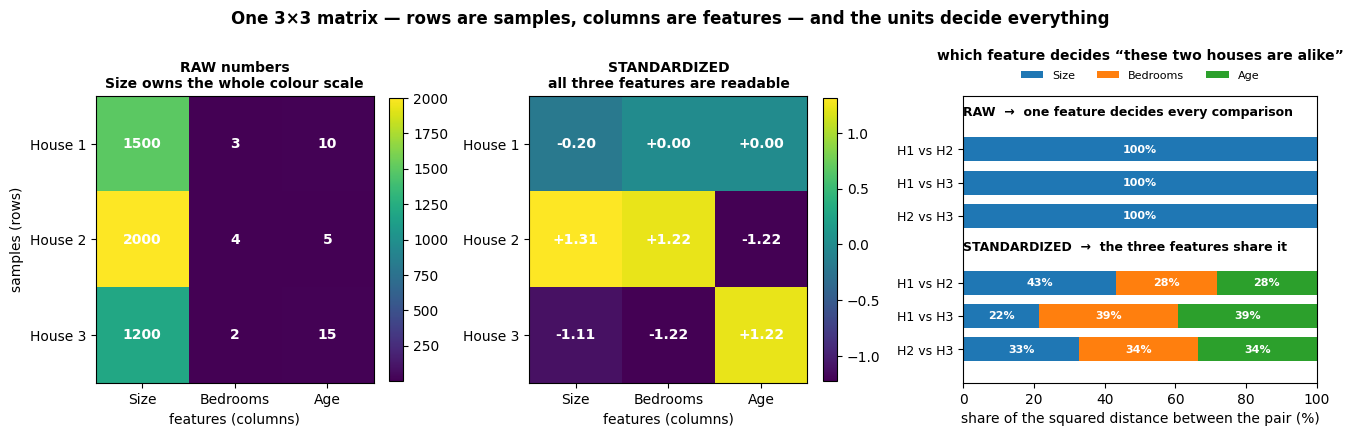

Reading the figure:
  - Panels 1 and 2 hold the SAME three houses. Only the units changed.
  - Left panel: Bedrooms and Age are the same shade of dark purple. Not because they are
    equal - House 1 has 3 bedrooms and House 3 has 15 years - but because next to 1500 sqft
    the difference between 3 and 15 is invisible on a shared colour scale.
  - Panel 3, first bar: Size contributes 99.99% of the squared distance
    between House 1 and House 2. The bar is labelled 100% because it rounds to it.
  - After standardizing, the largest single share drops to about 43%.

💡 The matrix layout (rows = samples, columns = features) is the format every ML library
   expects. The units inside it are your responsibility, and nothing warns you.


In [6]:
# The lesson's core claim, drawn: the rows-as-samples / columns-as-features layout is the contract
# every ML library assumes - and the UNITS inside that layout silently decide what "similar" means.
# WHY three panels: panels 1 and 2 are the SAME three houses, once in raw units and once standardized;
#      panel 3 is the distance table from the experiment above, redrawn so the imbalance is visible.
# HOW: standardizing means subtracting each column's mean and dividing by its standard deviation, so
#      every feature arrives at the distance formula carrying the same weight.

import numpy as np
import matplotlib.pyplot as plt

names = ["Size", "Bedrooms", "Age"]
row_labels = ["House 1", "House 2", "House 3"]
raw = houses_matrix.astype(float)                      # the matrix built in Example 2, unchanged
std = (raw - raw.mean(axis=0)) / raw.std(axis=0)       # same houses, unit-free columns

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), gridspec_kw={"width_ratios": [1, 1, 1.15]})

# Panels 1 and 2: the matrix itself. One colour scale per panel, so you can see what each scale hides.
for ax, M, title, fmt in [
        (axes[0], raw, "RAW numbers\nSize owns the whole colour scale", "{:.0f}"),
        (axes[1], std, "STANDARDIZED\nall three features are readable", "{:+.2f}")]:
    im = ax.imshow(M, cmap="viridis", aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(names)
    ax.set_yticks(range(3)); ax.set_yticklabels(row_labels)
    ax.set_xlabel("features (columns)")
    for i in range(3):                                  # write the value inside each cell
        for j in range(3):
            ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center",
                    color="w", fontweight="bold", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel("samples (rows)")

# Panel 3: for each pair of houses, what fraction of their squared distance each feature contributed.
ax = axes[2]
pairs = [(0, 1), (0, 2), (1, 2)]
shares = []
for M in (raw, std):
    for (i, j) in pairs:
        d2 = (M[i] - M[j]) ** 2                         # per-feature squared difference
        shares.append(100 * d2 / d2.sum())
shares = np.array(shares)

y = np.array([0, 1, 2, 4, 5, 6], dtype=float)           # a gap between the raw group and the std group
left = np.zeros(len(y))
for f, colour in enumerate(["tab:blue", "tab:orange", "tab:green"]):
    ax.barh(y, shares[:, f], left=left, color=colour, label=names[f], height=0.72)
    for yy, l, w in zip(y, left, shares[:, f]):
        if w > 7:
            ax.text(l + w / 2, yy, f"{w:.0f}%", ha="center", va="center",
                    fontsize=8, color="w", fontweight="bold")
    left += shares[:, f]

ax.set_yticks(y)
ax.set_yticklabels([f"H{i+1} vs H{j+1}" for _ in range(2) for (i, j) in pairs], fontsize=9)
ax.set_ylim(7.0, -1.6); ax.set_xlim(0, 100)
ax.text(0, -1.0, "RAW  \u2192  one feature decides every comparison", fontsize=9, fontweight="bold")
ax.text(0, 3.05, "STANDARDIZED  \u2192  the three features share it", fontsize=9, fontweight="bold")
ax.set_xlabel("share of the squared distance between the pair (%)")
ax.legend(fontsize=8, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 1.02), frameon=False)
ax.set_title("which feature decides \u201cthese two houses are alike\u201d",
             fontsize=10, fontweight="bold", pad=26)

fig.suptitle("One 3\u00d73 matrix \u2014 rows are samples, columns are features \u2014 and the units decide everything",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# The exact numbers behind the rounded labels in panel 3.
d2 = (raw[0] - raw[1]) ** 2
print("Reading the figure:")
print("=" * 62)
print("  - Panels 1 and 2 hold the SAME three houses. Only the units changed.")
print("  - Left panel: Bedrooms and Age are the same shade of dark purple. Not because they are")
print("    equal - House 1 has 3 bedrooms and House 3 has 15 years - but because next to 1500 sqft")
print("    the difference between 3 and 15 is invisible on a shared colour scale.")
print(f"  - Panel 3, first bar: Size contributes {100 * d2[0] / d2.sum():.2f}% of the squared distance")
print("    between House 1 and House 2. The bar is labelled 100% because it rounds to it.")
print("  - After standardizing, the largest single share drops to about 43%.")
print("\n💡 The matrix layout (rows = samples, columns = features) is the format every ML library")
print("   expects. The units inside it are your responsibility, and nothing warns you.")


**What to look for in the figure above.** All three panels describe the same three houses.

*Left panel* — the data matrix as ML libraries hold it: one row per house, one column per feature.
The `Size` column carries the entire colour range; `Bedrooms` and `Age` are painted the same dark
purple, even though one runs 2–4 and the other 5–15. The numbers are printed in each cell so you can
confirm the colours are lying about the differences, not the values.

*Middle panel* — identical layout, identical houses, after subtracting each column's mean and dividing
by its standard deviation. Now every cell sits between about −1.3 and +1.3, and the three features are
visibly different from one another.

*Right panel* — the consequence, which is the part that reaches your model. Each bar is one pair of
houses, split by how much each feature contributed to the squared distance between them. On raw units
the blue `Size` segment fills every bar (99.99%, printed under the figure). After standardizing, the
same three pairs split roughly 43/28/28, 22/39/39 and 33/34/34. Same houses, same distance formula,
a different answer to "which two are most alike" — and k-NN, k-means and any RBF kernel will act on
whichever answer you handed them.

---

## ⚠️ Where this breaks

- **A vector carries no units.** The table above is the warning: on the raw numbers *Size* supplies over
  99.9% of the squared distance between every pair of houses, and bedrooms and age contribute essentially
  nothing. Nothing in the vector itself tells you this — square feet and bedrooms sit side by side looking
  like equal numbers. Every method that measures distance (k-NN, k-means, PCA, RBF-kernel SVM) inherits
  that silent weighting. The assumption that must hold: your features are on comparable scales, or you
  standardized them first.
- **Rows-as-samples assumes the rows are interchangeable.** The layout says "each row is one independent
  observation." That is false for a time series, for repeated measurements from the same patient, and for
  the pixels of one image. If swapping two rows would change the meaning of your data, the matrix is
  hiding the structure that matters, and you need the models of Course 07 or Course 08 instead.
- **Cheaper alternative.** When your features are a handful of categories and your question is "how many
  of each?", a pandas `value_counts()` or a group-by answers it directly. Encoding categories as numbers
  so you can subtract them invents distances that do not exist — Riyadh minus Jeddah is not a number.


---

## 💬 Discuss

1. Bolukbasi and colleagues found stereotypes in vectors trained on articles written by professional
   journalists. Where does the responsibility sit — with the data, the algorithm, or the engineer who
   deployed it? Argue one position, then argue against yourself.
2. The distance table shows `Size` dominating every raw comparison. A colleague concludes "so standardize
   everything, always." Find one situation in this diploma's datasets where standardizing would destroy
   something you needed, and say what you would do instead.
3. You are asked to build a "similar properties" feature for a Saudi real-estate site. Which features go
   into the vector, which do you deliberately leave out, and what exactly do you tell the client that your
   distance measure cannot see?


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding vectors and matrices:

1. **Foundation for All ML**:
   - All ML algorithms use this data format
   - Ready to learn neural networks
   - Can understand data preprocessing

2. **Efficient Processing**:
   - Can process thousands of samples at once
   - Matrix operations are highly optimized
   - Enables modern deep learning

3. **Next Steps**:
   - Learn matrix operations (Example 2)
   - Understand eigenvalues (Example 3)
   - Apply to real ML problems

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand how to implement this concept.

**AFTER this notebook**: We can:
- ✅ Understand WHY this concept matters
- ✅ Implement HOW it works
- ✅ See what happens AFTER (results and implications)
- ✅ Apply it to real ML scenarios

**Next Steps**: 
- 📓 Review other examples in this module
- 📓 Complete exercises
- 📓 Move to next module

---

## ✅ Example Complete!

You've learned this concept using the **Why → How → After** methodology!

**Key Takeaway**: Understanding WHY, HOW, and AFTER helps you master concepts deeply!

## 📚 References

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 2: Linear Algebra. MIT Press. <https://www.deeplearningbook.org/>
2. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 2: Linear Algebra. Cambridge University Press. <https://mml-book.github.io/>
3. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357–362. <https://doi.org/10.1038/s41586-020-2649-2>
4. Zhang et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. arXiv. <https://arxiv.org/abs/2506.05176> — the vectors a 2026 system actually compares are embeddings produced by a model like this one.
5. Enevoldsen, K., Chung, I., Kerboua, I., Kardos, M., Mathur, A., et al. (2025). *MMTEB: Massive Multilingual Text Embedding Benchmark*. arXiv. <https://arxiv.org/abs/2502.13595> — how those vector representations are chosen in practice: by benchmark, and across many languages.
